# 📌 Regressão Linear Simples

A **Regressão Linear Simples** é um método estatístico utilizado para modelar a relação entre duas variáveis:
- uma variável **independente** (ou preditora), denotada por $X$
- e uma variável **dependente** (ou resposta), denotada por $y$.

O objetivo é encontrar uma equação de reta que melhor represente essa relação.

Essa equação assume a forma:

$$
\Huge y = β_0 + β_1 x + ϵ
$$

onde:
- $y$ é o valor previsto (variável dependente),
- $x$ é a variável independente,
- $β_1$ é o **coeficiente angular** (inclinação da reta),
- $β_0$ é o **coeficiente linear** (intercepto da reta com o eixo $y$).

A inclinação da reta ($β_1$) indica o quanto $y$ varia a cada unidade de variação em $X$, enquanto o intercepto ($β_0$) representa o valor de $y$ quando $x = 0$.

## 💡 Exemplo didático

Um corretor de imóveis coletou alguns dados sobre o **preço de apartamentos** em uma mesma região.  
A única variável considerada foi a **metragem em m²** do apartamento.

Os dados estão resumidos na tabela abaixo:

| Metragem (m²) | Preço (R$ mil) |
|---------------|----------------|
| 50            | 200            |
| 60            | 240            |
| 70            | 270            |
| 80            | 310            |
| 90            | 360            |

**Tarefas:**
- Plote os pontos em um gráfico de dispersão.  
- Ajuste uma Regressão Linear Simples para estimar o preço a partir da metragem.  
- Mostre a equação da reta ajustada.  
- Visualize a reta sobre os dados originais.  
- Estime o preço previsto para um apartamento de **75 m²**.

### **1. Importação das bibliotecas**

- `numpy (np)` → Usada para criar e manipular arrays numéricos de forma eficiente.
- `matplotlib.pyplot (plt)` → Biblioteca para visualização de dados, utilizada para criar gráficos e plots.
- `sklearn.linear_model.LinearRegression` → Classe do scikit-learn que implementa o algoritmo de Regressão Linear, usado para modelar a relação entre variáveis independentes (X) e dependente (y).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

> **🎯 Momento de Praticar**

### **2. Gerando dados artificiais**

Nesta etapa, usamos o **Matplotlib** para visualizar os dados:  

- **Gráficos de dispersão (`plt.scatter`)** são ideais para observar a relação entre duas variáveis.  
- Com isso, conseguimos ver se os pontos seguem algum padrão — aqui esperamos algo parecido com uma linha, já que a relação é linear.  
- A visualização é um passo essencial em Machine Learning, pois permite entender a distribuição dos dados antes de aplicar qualquer modelo.  


In [ ]:
np.random.seed(42)  # reprodutibilidade

X = np.linspace(40, 100, 100).reshape(-1, 1)  # metragem de 40 a 100 m²

e = np.random.randn(100) * 20  # ruído
y = 3.5 * X.flatten() + 20 + e  # preço em mil R$, com ruído

X[:10], y[:10]

In [ ]:
plt.scatter(X, y, color="blue", label="Dados reais")

plt.title("Regressão Linear Simples")
plt.xlabel("Metragem (m²)")
plt.ylabel("Preço (R$ mil)")
plt.legend()
plt.show()

### **3. Treinamento do modelo**

A classe `LinearRegression()` cria um objeto do modelo de regressão linear da biblioteca *scikit-learn*.  

Esse objeto ainda não está treinado, mas já contém os métodos necessários para ajustar os dados (`fit`), prever novos valores (`predict`) e acessar parâmetros do modelo (como coeficientes e intercepto).  


In [ ]:
model = LinearRegression()
model.fit(X, y)

model

In [ ]:
# Coeficientes
b0 = model.intercept_ # coef linear
b1 = model.coef_[0] # coef ang

print(f"Equação da reta: y = {b0} + {b1} * x")

### **4. Fazer previsões**

O método **`.predict(X)`** realiza previsões com base no modelo já treinado.  
Na regressão linear, cada valor previsto corresponde ao cálculo da equação da reta ajustada:  
$$
y = \beta_0 + \beta_1 x + ϵ
$$  
Dessa forma, para cada valor de entrada em `X`, o modelo retorna a saída estimada `y`, permitindo comparar previsões com os dados reais.  


In [ ]:
# Previsão para 75 m²
x_novo = np.array([[75]]) # é um array 2D, de shape (1,1)
y_novo = model.predict(x_novo)

print(f"Preço previsto para 75 m²: R$ {y_novo[0]:.2f} mil")

### **5. Visualização dos dados**

In [ ]:
# Plot
y_pred = model.predict(X)

plt.plot(X, y_pred, color="red", label="Reta ajustada")

plt.scatter(X, y, color="blue", label="Dados reais")
plt.scatter(x_novo, y_novo, color="yellow", edgecolors="k", s=150, marker="*", label="Previsão 75 m²")

plt.title("Regressão Linear Simples")
plt.xlabel("Metragem (m²)")
plt.ylabel("Preço (R$ mil)")
plt.legend()
plt.show()

# 📌 Regressão Linear Múltipla

## 💡 Exemplo didático

Agora, vamos evoluir o exemplo anterior.
Na prática, o preço de um apartamento dificilmente depende apenas da metragem em m².

Outros fatores também influenciam, como o número de quartos, a idade do imóvel, a localização, entre muitos outros.

Um corretor de imóveis ampliou a coleta de dados e, além da metragem, passou a considerar também o número de quartos em cada apartamento.

Com isso, podemos aplicar uma **Regressão Linear Múltipla**, ou seja, um modelo que utiliza mais de uma variável independente para prever o preço.

### **1. Importação das bibliotecas**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D  # para gráfico 3D

### **2. Gerando dados artificiais**

Fixamos a nossa seed de aletoriedade para reprodutibilidade dos dados criados

In [ ]:
np.random.seed(42)

**➡️ Gerando variáveis independentes (features):**

- Aqui criamos 100 apartamentos fictícios.
- Cada apartamento tem duas informações: metragem (contínua) e número de quartos (inteiro).

In [ ]:
samples = 80

metragem = np.linspace(40, 200, samples)    # valores de 40 a 120 m²
quartos = np.random.randint(1, 5, samples)  # valores entre 1 e 4

metragem[:10], quartos[:10]

**➡️ Criando a variável dependente (target):**

O preço é definido a partir de uma fórmula artificial:
- Cada m² contribui com R\$ 3,2 mil.
- Cada quarto contribui com R\$ 50 mil.
- O intercepto é R\$ 30 mil.

E adicionamos um ruído aleatório (`np.random.randn()*20`) para simular variação real.

In [ ]:
e = np.random.randn(samples) * 20
preco = 3.2 * metragem + 50 * quartos + 30 + e

preco[:10]

**➡️ Unindo em um dataset (X, y):**

In [ ]:
df = pd.DataFrame({
    "metragem": metragem,
    "quartos": quartos,
    "preco": preco
})

df.head()

 Visualização dos dados

In [ ]:
plt.figure(figsize=(12,5))

# Gráfico 1
plt.subplot(1, 2, 1)   # 1 linha, 2 colunas, posição 1
plt.scatter(df['metragem'], df['preco'], color="blue")
plt.title("Regressão Linear Múltipla")
plt.xlabel("Metragem (m²)")
plt.ylabel("Preço (R$ mil)")

# Gráfico 2
plt.subplot(1, 2, 2)   # 1 linha, 2 colunas, posição 2
plt.scatter(df['quartos'], df['preco'], color="green")
plt.title("Regressão Linear Múltipla")
plt.xlabel("Quartos")
plt.ylabel("Preço (R$ mil)")

plt.tight_layout()
plt.show()

> **🎯 Momento de Praticar**

### **3. Divisão dos dados em Treino e Teste**

Parâmetros do train_test_split

A função `train_test_split()` permite controlar como os dados são divididos em treino e teste por meio de alguns parâmetros importantes:

- **`test_size`** → define o tamanho do conjunto de teste. Pode ser um número absoluto de amostras ou uma fração (ex.: `0.2` significa 20%).  
- **`train_size`** → define o tamanho do conjunto de treino. Se não for especificado, é calculado automaticamente como o complemento de `test_size`.  
- **`random_state`** → controla a semente do gerador de números aleatórios, garantindo que a divisão seja **reproduzível**.  
- **`shuffle`** → se `True` (padrão), embaralha os dados antes da divisão, evitando que a ordem original influencie o modelo.


In [ ]:
X = df.drop(columns=['preco']).copy()
y = df['preco'].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X.shape, y.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

### **4. Treinamento do modelo**

In [ ]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

In [ ]:
intercepto = modelo.intercept_
coef_metragem, coef_quartos = modelo.coef_

print(f"Equação do modelo: y = {intercepto:.2f} + ({coef_metragem:.2f} * metragem) + ({coef_quartos:.2f} * quartos)")

### **5. Fazer previsões**

Previsão para um apartamento de 80m² e 3 quartos

In [ ]:
# Previsão para um apartamento de 80m² e 3 quartos
x_ponto = np.array([[80, 3]])
y_ponto_pred = modelo.predict(x_ponto)
print(f"Preço previsto para 80m² e 3 quartos: R${y_pred[0]:.2f} mil")

**➡️ Plot de gráfico 3D (Metragem x Quartos x Valor)**

In [ ]:
# Cria um objeto 3D
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], y_train, color="blue", alpha=0.6, label="Dados de treino")
ax.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], y_test, color="red", alpha=0.6, label="Dados de teste")

# Criar grid para a superfície
metragem_grid, quartos_grid = np.meshgrid(
    np.linspace(X.iloc[:,0].min(), X.iloc[:,0].max(), samples),
    np.linspace(X.iloc[:,1].min(), X.iloc[:,1].max(), samples)
)
X_grid = np.column_stack(
    (metragem_grid.ravel(),
     quartos_grid.ravel())
)
y_grid = modelo.predict(X_grid).reshape(metragem_grid.shape)

# # Superfície do plano
ax.plot_surface(metragem_grid, quartos_grid, y_grid, color="red", alpha=0.4)

ax.set_xlabel("Metragem (m²)")
ax.set_ylabel("Quartos")
ax.set_zlabel("Preço (R$ mil)")
plt.legend()
plt.show()


### **6. Avaliação do modelo**

In [ ]:
y_pred = modelo.predict(X_test)

**➡️ R² Score (Coeficiente de Determinação):**  
- Indica o quanto da variação da variável dependente (`y`) é explicada pelo modelo.
- Um valor de 0,85, por exemplo, significa que 85% da variância nos dados de saída (`y`) é explicada pelas variáveis de entrada (`X`).
- Valores próximos de 1 sugerem um bom desempenho, enquanto valores negativos indicam que o modelo é pior do que simplesmente prever a média dos valores.


In [ ]:
r2_model = modelo.score(X_test, y_test)
print(f"Coeficiente de determinação (R²): {r2_model:.4f}")

In [ ]:
r2 = r2_score(y_test, y_pred)
print(f"Coeficiente de determinação (R²): {r2:.4f}")

**➡️ MAE (Erro Absoluto Médio):**  
- Informa o erro médio, em valor absoluto, entre as previsões e os dados reais.
- Se o MAE for 3,2, isso significa que, em média, o modelo erra 3,2 unidades na predição.
- É fácil de interpretar e não é influenciado por outliers, mas não diferencia pequenos de grandes erros.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")

**➡️ MSE (Erro Quadrático Médio):**  
- Mede o erro médio ao quadrado entre as previsões e os valores reais.
- Por elevar os erros ao quadrado, valores maiores indicam que o modelo teve erros significativos.
- Um MSE alto pode sinalizar a presença de outliers ou um modelo mal ajustado, e é útil quando se quer penalizar mais fortemente erros grandes.

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")

**➡️ RMSE (Raiz do Erro Quadrático Médio):**  
- É a raiz quadrada do MSE, trazendo o erro médio para a mesma escala da variável predita (`y`).
- Um RMSE de 4,5, por exemplo, indica que o modelo erra em média 4,5 unidades.
- Assim como o MSE, é sensível a outliers, mas sua escala facilita a comparação direta com os valores reais.

In [ ]:
rmse = np.sqrt(mse)
print(f"Raiz do Erro Quadrático Médio (RMSE): R$ {rmse:.4f} mil")

**➡️ Correlação entre valor predito e valor real**

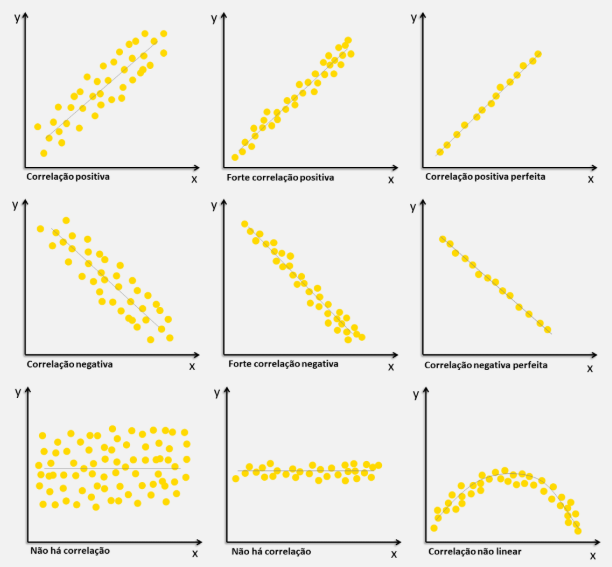

**Dispersão dos pontos**

- Se os pontos estão bem concentrados em torno da reta → o modelo tem boa acurácia.
- Se os pontos estão muito espalhados → o modelo tem erros maiores e/ou inconsistentes.

⚠️ **IMPORTANTE**: não confundir com a reta da **Regressão Linear**

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='green', label='Valores Preditos vs. Reais')

range_y = [y_test.min(), y_test.max()]
plt.plot(range_y, range_y, color='pink', linestyle='--', label='Reta Ideal')

plt.xlabel("Valores Reais (y)")
plt.ylabel("Valores Preditos (y_pred)")
plt.title("Valores Reais vs. Preditos")
plt.legend()
plt.grid(True)
plt.show()

O nosso gráfico mostra:

- Boa aderência à reta (os pontos seguem de perto a linha vermelha).

- Alguns desvios visíveis (uns pontos abaixo e outros acima), mas sem outliers gritantes.

- Isso sugere que o modelo generalizou bem e provavelmente tem um R² alto.

# 📊 Exemplo real - Predição de Custos Médicos Individuais

🎯 **Objetivo do Desafio**
Seu desafio é construir, treinar e avaliar um modelo de **regressão linear** (simples ou múltipla) capaz de **prever o valor dos custos médicos individuais** cobrados pelo seguro saúde, com base em dados demográficos e de estilo de vida dos beneficiários.

<br>

📦 **Conjunto de Dados**
Você utilizará o dataset **Medical Cost Personal Datasets**, que contém informações de beneficiários de seguro saúde nos Estados Unidos. O dataset inclui as seguintes variáveis:

- `age`: Idade
- `sex`: Sexo (masculino ou feminino)
- `bmi`: Índice de Massa Corporal
- `children`: Número de filhos/dependentes
- `smoker`: Fumante ou não
- `region`: Região de residência
- `charges`: **(variável alvo)** Custo médico individual

<br>

🧠 **Tarefas Propostas**
1. **Análise Exploratória de Dados (EDA)**
   - Visualize a distribuição das variáveis.
   - Verifique correlações entre atributos e a variável `charges`.
   - Detecte possíveis outliers e valores discrepantes.

2. **Pré-processamento dos Dados**
   - Divida os dados em conjuntos de treino e teste (ex: 80/20).
   - Codifique variáveis categóricas (`sex`, `smoker`, `region`).
   - Normalize os dados numéricos se necessário.

3. **Treinamento do Modelo**
   - Implemente os modelos **regressão linear simples** e **regressão linear múltipla** **regressão polinomial**.
   - Treine os modelos usando o conjunto de treino.

4. **Avaliação do Modelo**
   - Meça o desempenho com métricas como:
     - **R²**
     - **MAE** (Erro Absoluto Médio)
     - **MSE** (Erro Quadrático Médio)
     - **RMSE** (Raiz do Erro Quadrático Médio)

5. **Interpretação**
   - Qual modelo obteve melhor performance?

## **1. Importação das bibliotecas**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from scipy.sparse import issparse

## **2. Carregamento dos Dados**

In [ ]:
insurance_url = 'https://raw.githubusercontent.com/matheusvanzan/Machine-Learning-Examples/refs/heads/master/datasets/insurance.csv'

In [ ]:
df = pd.read_csv(insurance_url)

In [ ]:
# salvar copia
df_original = df.copy()

In [ ]:
df.head()

> **🎯 Momento de Praticar**

## **3. Análise Exploratória**

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
categorical = df.select_dtypes(include='object').columns.tolist()
categorical

In [ ]:
numerical = df.select_dtypes(include='number').columns.tolist()
numerical

In [ ]:
# df['age'] = df['age'].astype(int)
# df['children'] = df['children'].astype(int)

In [ ]:
df.isnull().sum()

In [ ]:
df.isnull().any(axis=1).sum()

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

In [ ]:
df[df.duplicated(keep=False)]

In [ ]:
df.drop_duplicates(keep='first', inplace=True)

In [ ]:
df.shape

In [ ]:
df['age'] = df['age'].astype(int)
df['children'] = df['children'].astype(int)

In [ ]:
df.nunique()

In [ ]:
df.describe()

In [ ]:
def plot_histograms(df, column, bins, category_col=None):
    plt.figure(figsize=(8, 5))

    if category_col:
        sns.histplot(data=df, x=column, hue=category_col, kde=True, bins=bins, palette='tab10', element='step')
        plt.title(f'Histograma de {column} por {category_col}')
    else:
        sns.histplot(data=df, x=column, kde=True, bins=bins, color='tab:blue', element='step')
        plt.title(f'Histograma de {column}')

    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.show()

In [ ]:
bins = int(np.sqrt(len(df)))

In [ ]:
for column in df.columns:
    print('')
    plot_histograms(df, column, bins, 'smoker')

In [ ]:
def plot_boxplots_category(df, column, category_col=None):
    plt.figure(figsize=(8, 5))

    if category_col:
        sns.boxplot(data=df, x=category_col, y=column, hue=category_col, palette='tab10')
        plt.title(f'Boxplot de {column} por {category_col}')
        plt.xlabel(category_col)
    else:
        sns.boxplot(data=df, y=column)
        plt.title(f'Boxplot de {column}')
        plt.xlabel('')

    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

In [ ]:
for column in numerical:
  plot_boxplots_category(df, column, 'smoker')

In [ ]:
def plot_correlation_matrix(df):
    corr_df = df[df.select_dtypes(include=['number']).columns]
    plt.figure(figsize=(10, 8))
    correlation_matrix = corr_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlação')
    plt.show()

In [ ]:
plot_correlation_matrix(df)

In [ ]:
sns.pairplot(df, hue='smoker')
plt.show()

In [ ]:
def remove_outliers_iqr(df, column, category_col=None):
    if category_col:
        filtered_df = pd.DataFrame()
        for category in df[category_col].unique():
            subset = df[df[category_col] == category]
            Q1 = subset[column].quantile(0.25)
            Q3 = subset[column].quantile(0.75)
            IQR = Q3 - Q1
            mask = (subset[column] >= Q1 - 1.5 * IQR) & (subset[column] <= Q3 + 1.5 * IQR)
            filtered_df = pd.concat([filtered_df, subset[mask]])
        return filtered_df
    else:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)
        return df[mask]

In [ ]:
for column in numerical:
  df = remove_outliers_iqr(df, column, 'smoker')

In [ ]:
df_processado = df.copy()

In [ ]:
df_original.shape

In [ ]:
df_processado.shape

## **4. Pré-processamento dos dados**

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

**⚠️ Cuidado com o *Data Leakage***

Um dos erros mais comuns, e perigosos, no desenvolvimento de modelos de Machine Learning* é o chamado **data leakage** (ou "vazamento de dados"). Ele ocorre quando informações do conjunto de **teste** acabam sendo usadas, direta ou indiretamente, durante o **treinamento** do modelo.

Esse vazamento pode acontecer, por exemplo, ao aplicar transformações como normalização, encoding ou imputação **antes** da divisão entre treino e teste, ou ao utilizar parâmetros calculados com base em todo o conjunto de dados. Isso faz com que o modelo "veja o futuro" e tenha um desempenho artificialmente bom — mas que não se sustenta em dados novos do mundo real.

> **Regra**: sempre ajuste (fit) transformações **apenas** no conjunto de treino, e só depois aplique (transform) ao conjunto de teste, usando os mesmos parâmetros.

In [ ]:
df.head()

In [ ]:
df.describe()

In [ ]:
X = df.drop(columns=['charges']).copy()
y = df['charges'].copy()

**Divisão dos dados em treino e teste**

Antes de treinar o modelo de classificação, precisamos dividir nosso conjunto de dados em duas partes: uma para o treinamento do modelo e outra para a avaliação de seu desempenho. Essa divisão é fundamental para garantir que o modelo seja avaliado com dados que ele nunca viu antes, simulando situações reais de generalização.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **🔎 StandardScaler**

**Normalização/Padronização das variáveis numéricas**

Muitos algoritmos são sensíveis a escala dos dados, o que pode influenciar de forma desproporcional o resultado da classificação. Por exemplo, uma variável com valores entre 0 e 1000 poderá ter muito mais peso na classificação do que outra variando entre 0 e 1, mesmo que essa diferença de escala não represente maior importância no contexto do problema.

In [ ]:
categorical = X_train.select_dtypes(include='object').columns.tolist()
categorical

In [ ]:
numerical = X_train.select_dtypes(include='number').columns.tolist()
numerical

O **StandardScaler** é uma técnica de *padronização* (também conhecida como normalização z-score), usada para transformar os dados de forma que eles passem a ter **média igual a 0** e **desvio padrão igual a 1**.  

Essa transformação é especialmente útil quando os dados têm uma distribuição próxima da normal ou quando o algoritmo de aprendizado é sensível à escala dos dados — como nos casos de regressão linear, SVM e redes neurais.

***Como funciona:***

A transformação é feita por meio da seguinte fórmula:

$$
z = \frac{x - \mu}{\sigma}
$$

Onde:
- $ x $ é o valor original do dado,  
- $ \mu $ é a média de todos os valores da variável,  
- $ \sigma $ é o desvio padrão desses valores,  
- $ z $ é o novo valor padronizado.  

Em outras palavras, subtrai-se a média de cada valor e divide-se o resultado pelo desvio padrão. Isso centraliza os dados em torno de zero e os coloca em uma escala comum.

In [ ]:
X_train.describe()

In [ ]:
X_train_standard = X_train.copy()

In [ ]:
scaler = StandardScaler()
scaler

In [ ]:
X_train_standard[numerical] = scaler.fit_transform(X_train_standard[numerical])

In [ ]:
X_train_standard.describe().round(2)

> **🎯 Momento de Praticar**

### **🔎 MinMaxScaler**

O **MinMaxScaler** é uma técnica de *normalização min-max* usada para reescalar os dados de modo que eles fiquem **dentro de um intervalo específico**, geralmente entre **0 e 1**.  

Essa transformação **mantém a forma da distribuição dos dados** — ou seja, não altera a relação entre os valores — mas ajusta a escala para que todos os dados fiquem dentro do intervalo desejado. É útil quando as variáveis têm diferentes unidades de medida ou faixas de valores.

Essa técnica é especialmente útil para algoritmos baseados em distância ou em gradiente, nos quais a escala dos dados impacta diretamente o desempenho, como o KNN e o SGD.

***Como funciona:***
A fórmula da normalização min-max é:

$$
x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

Onde:
- $ x $ é o valor original do dado,  
- $ x_{min} $ é o menor valor da variável,  
- $ x_{max} $ é o maior valor da variável,  
- $ x_{norm} $ é o novo valor normalizado, entre 0 e 1.  

Em resumo, essa técnica "encaixa" todos os valores dentro do intervalo desejado, mantendo suas proporções relativas.

In [ ]:
X_train.describe().round(2)

In [ ]:
X_train_min_max = X_train.copy()

In [ ]:
scaler = MinMaxScaler()
scaler

In [ ]:
X_train_min_max[numerical] = scaler.fit_transform(X_train_min_max[numerical])

In [ ]:
X_train_min_max.describe().round(2)

### **🔎 One-Hot Encoding**

O **One-Hot Encoding** é uma técnica usada para converter **variáveis categóricas** (como cores, países, ou tipos) em um formato que pode ser entendido por algoritmos de machine learning, que geralmente trabalham apenas com valores numéricos.

Em vez de atribuir números inteiros para categorias (o que implicaria uma ordem ou hierarquia que muitas vezes não existe), o One-Hot Encoding transforma cada categoria em uma **nova coluna binária**, com valores 0 ou 1 indicando a presença ou ausência daquela categoria.

***Como funciona:***

A variável `color` com três categorias: `red`, `blue`, e `green`.

O One-Hot Encoding transforma isso em:

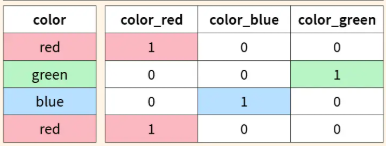

Cada linha tem exatamente um valor "1" e os demais "0", representando de forma clara e sem ambiguidade a categoria original.

***Quando usar:***
- Ideal para variáveis categóricas **nominais** (sem ordem natural entre as categorias).
- Útil em algoritmos que não lidam bem com variáveis categóricas diretamente (como regressão linear, redes neurais, SVM etc.).
- Pode aumentar muito o número de colunas se houver muitas categorias distintas.

**Utilizando `pd.get_dummies`**

O `pandas` oferece uma forma rápida e prática de aplicar one-hot encoding com a função `pd.get_dummies()`. Ela transforma cada categoria de uma coluna em uma nova coluna binária (0 ou 1), indicando a presença daquela categoria em cada linha.

Por exemplo, a coluna `sex` com os valores `['male', 'demale']` se transforma em duas colunas: `sex_male` e `sex_female`.

In [ ]:
X_train_dummy = pd.get_dummies(X_train, columns=categorical, dtype=float)

In [ ]:
X_train_dummy.head()

**Utilizando `OneHotEncoder`**

Outra opção, mais flexível e integrada ao pipeline de machine learning do `scikit-learn`, é o uso do `OneHotEncoder`. Esse método é especialmente útil quando combinamos diferentes etapas de pré-processamento e treinamento de modelo em um único pipeline.

In [ ]:
X_train

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
encoder

In [ ]:
enc1 = OneHotEncoder(sparse_output=True)
enc2 = OneHotEncoder(sparse_output=False)

X1 = enc1.fit_transform(X_train[categorical])
X2 = enc2.fit_transform(X_train[categorical])

In [ ]:
X1

In [ ]:
X2

In [ ]:
X_train_one_hot = encoder.fit_transform(X_train[categorical])
type(X_train_one_hot)

In [ ]:
encoder.get_feature_names_out()

In [ ]:
X_train_one_hot = pd.DataFrame(X_train_one_hot, columns=encoder.get_feature_names_out())
X_train_one_hot.head()

**⚠️ Multicolinearidade no One-Hot (Dummy Trap)**

- Ao transformar uma variável categórica com k categorias em k colunas binárias (one-hot) e manter o intercepto, as colunas passam a ser linearmente dependentes (somam 1 em cada linha).

- Isso gera multicolinearidade perfeita: os coeficientes ficam não identificáveis/instáveis, dificultando a interpretação (embora as previsões geralmente ainda funcionem).

- Solução padrão: escolher uma categoria de referência e remover uma coluna por variável categórica.

**Observação**: modelos baseados em árvores/boosting não sofrem com isso; o problema é mais crítico em modelos lineares (Regressão Linear ou Logística).


In [ ]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoder

In [ ]:
X_train_one_hot = encoder.fit_transform(X_train[categorical])
X_train_one_hot = pd.DataFrame(X_train_one_hot, columns=encoder.get_feature_names_out())
X_train_one_hot.head()

### **🔎 ColumnTransformer**

O **ColumnTransformer** permite aplicar diferentes transformações em colunas específicas de um dataset ao mesmo tempo. Por exemplo, você pode padronizar colunas numéricas e aplicar one-hot encoding em colunas categóricas, tudo de uma vez. Ele junta os resultados em uma única saída, facilitando o pré-processamento de dados com tipos variados. Além disso, é amplamente utilizado em **pipelines**, integrando o pré-processamento de forma automática e organizada ao fluxo completo de modelagem.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical)
    ]
)

In [ ]:
X_processed = preprocessor.fit_transform(X_train)
X_processed

In [ ]:
categorical_ohe = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical)
categorical_ohe

In [ ]:
column_names = numerical + list(categorical_ohe)
column_names

In [ ]:
X_processed = pd.DataFrame(X_processed, columns=column_names)
X_processed.head()

## **5. Treinamento do modelo**

### **➡️ Regressão Linear Simples**

In [ ]:
df.head()

Para a Regressão Linear Simples, preciso escolher apenas uma *feature* para montar a minha variável independente `X`.

In [ ]:
X = df[['bmi']].copy()
y = df['charges'].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lin_reg = Pipeline([
    ('preprocessing', StandardScaler()),
    ('regressor', LinearRegression())
])

In [ ]:
lin_reg.fit(X_train, y_train)

In [ ]:
y_pred = lin_reg.predict(X_train)

**Avaliação do Desempenho do Modelo nos Dados de Teste**

In [ ]:
y_pred = lin_reg.predict(X_test)

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, alpha=0.6, label='Dados gerados')
plt.plot(X_test, y_pred, color='red', label='Reta de regressão')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title(f"Regressão Linear Simples - {X.columns[0]}")

plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Valores Preditos vs. Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Reta Ideal')
plt.xlabel("Valores Reais (y)")
plt.ylabel("Valores Preditos (y_pred)")
plt.title("Gráfico de Paridade - Reais vs. Preditos")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
r2 = lin_reg.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [ ]:
print(f"Coeficiente de determinação (R²): {r2:.4f}")
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")

> **🎯 Momento de Praticar**

### **➡️ Regressão Linear Múltipla**

In [ ]:
df.head()

Na Regressão Linear Múltipla, eu posso utilizar todas as *features*.

In [ ]:
X = df.drop(columns=['charges']).copy()
y = df['charges'].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
categorical = X_train.select_dtypes(include='object').columns.tolist()
categorical

In [ ]:
numerical = X_train.select_dtypes(include='number').columns.tolist()
numerical

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical)
    ]
)

In [ ]:
lin_reg = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

In [ ]:
lin_reg.fit(X_train, y_train)

In [ ]:
y_pred = lin_reg.predict(X_train)

**Avaliação do Desempenho do Modelo nos Dados de Teste**

In [ ]:
y_pred = lin_reg.predict(X_test)

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Valores Preditos vs. Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Reta Ideal')
plt.xlabel("Valores Reais (y)")
plt.ylabel("Valores Preditos (y_pred)")
plt.title("Gráfico de Paridade - Reais vs. Preditos")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
r2 = lin_reg.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [ ]:
print(f"Coeficiente de determinação (R²): {r2:.4f}")
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")

---

# **📌 Método do Gradiente Descendente**

O gráfico abaixo é apenas uma representação ilustrativa para mostrar a ideia do Gradiente Descendente.
A curva em formato de parábola representa a função de erro: quanto mais alto o ponto, maior o erro do modelo; quanto mais baixo, menor o erro.

A bolinha vermelha começa em um ponto qualquer e vai descendo a curva em pequenos passos, sempre na direção onde o erro diminui.
Cada passo sucessivo reduz o erro até chegar ao ponto mais baixo (mínimo).

Esse gráfico não mostra o funcionamento real do algoritmo em um dataset, mas serve apenas para exemplificar o comportamento geral do método: ir ajustando os coeficientes do modelo de forma incremental até encontrar valores que minimizem o erro.

In [ ]:
# Função custo (parabólica fictícia)
def J(beta):
    return (beta - 2)**2 + 1  # mínimo em beta=2

# Valores para desenhar a curva
beta_vals = np.linspace(-1, 5, 100)
J_vals = J(beta_vals)

> Exemplo com um passo curto

In [ ]:
# Simulação de passos do gradiente descendente
steps = [-0.5, 0.5, 1.5, 2.5, 2.1, 2.0]  # valores de beta em cada iteração
errors = J(np.array(steps))

# Plot
plt.figure(figsize=(8,6))
plt.plot(beta_vals, J_vals, label="Função de erro (custo)")
plt.scatter(steps, errors, color="red")
plt.plot(steps, errors, color="red", linestyle="--", label="Passos do gradiente")
plt.xlabel("Coeficiente (β)")
plt.ylabel("Erro J(β)")
plt.title("Intuição do Gradiente Descendente")
plt.legend()
plt.show()


> Exemplo com um passo longo

In [ ]:
# Simulação de passos do gradiente descendente
steps = [ -0.5, 4.0, 0.6, 3.1, 1.5, 2.1, 2.0 ]  # posições sucessivas
errors = J(np.array(steps))

# Plot
plt.figure(figsize=(8,6))
plt.plot(beta_vals, J_vals, label="Função de erro (custo)")
plt.scatter(steps, errors, color="red")
plt.plot(steps, errors, color="red", linestyle="--", label="Passos do gradiente")
plt.xlabel("Coeficiente (β)")
plt.ylabel("Erro J(β)")
plt.title("Intuição do Gradiente Descendente")
# plt.legend()
plt.show()


### Utilização do SGDRegressor

O `SGDRegressor` do scikit-learn faz a mesma coisa que o `LinearRegression`, mas usando gradiente descendente estocástico em vez da solução exata dos mínimos quadrados.

🔎 Diferenças para o `LinearRegression`

- `LinearRegression` → calcula a solução exata via mínimos quadrados.
- `SGDRegressor` → ajusta os coeficientes de forma incremental, percorrendo os dados em lotes (ou amostras individuais).
- A interface é quase idêntica: `.fit(X, y)` e `.predict(X)` funcionam igual.
- O que muda é como os coeficientes são encontrados.

`SGDRegressor` é muito mais escalável para datasets grandes, onde calcular a inversa da matriz seria inviável.

In [ ]:
from sklearn.linear_model import SGDRegressor

> **🎯 Momento de Praticar**

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical)
    ]
)

In [ ]:
# Modelo com Gradiente Descendente Estocástico
modelo_sgd = SGDRegressor(
    max_iter=1000,            # número máximo de iterações
    tol=1e-3,                 # critério de parada
    eta0=0.01,                # taxa de aprendizado inicial
    learning_rate="constant", # mantém taxa de aprendizado fixa
    random_state=42
)

In [ ]:
sgd_reg = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', modelo_sgd)
])

In [ ]:
sgd_reg.fit(X_train, y_train)

y_pred_sgd = sgd_reg.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred_sgd)
mae = mean_absolute_error(y_test, y_pred_sgd)
mse = mean_squared_error(y_test, y_pred_sgd)
rmse = np.sqrt(mse)

In [ ]:
print(f"Coeficiente de determinação (R²): {r2:.4f}")
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")

# 📌 Regressão Polinomial

A **Regressão Polinomial** é uma variação da regressão linear que permite modelar relações **não lineares** entre a variável **dependente** $y$ e a(s) variável(is) **independente(s)** $x$.  

Apesar de utilizar uma equação polinomial, ainda é considerada um tipo de **regressão linear**, pois continua linear em relação aos coeficientes.  

A equação assume a forma:  

$$
y = b_0 + b_1x + b_2x^2 + b_3x^3 + \dots + b_nx^n
$$  

onde:  
- $y$ é o valor previsto (variável dependente),  
- $x$ é a variável independente,  
- $b_0$ é o **coeficiente linear** (intercepto),  
- $b_1, b_2, \dots, b_n$ são os coeficientes associados a cada potência de $x$ até o grau $n$.  

Ao incluir potências crescentes de $x$, o modelo consegue capturar **curvaturas e padrões mais complexos** nos dados, que uma regressão linear simples ou múltipla não representaria bem.  

A escolha do grau $n$ é fundamental:  
- Graus baixos podem **subestimar a complexidade** do problema (*underfitting*).  
- Graus muito altos podem levar a um **excesso de ajuste** aos dados de treino (*overfitting*).  

> **PolynomialFeatures no Scikit-learn**  

A classe `PolynomialFeatures()` do módulo `sklearn.preprocessing` é usada para gerar **novas variáveis derivadas de potências do atributo original**.  
Essa transformação permite que modelos lineares, como a regressão linear, aprendam **relações não lineares** entre `X` e `y`.  

Exemplo:  
- Ao aplicar `PolynomialFeatures(degree=2)` em uma variável `x`, são criadas as colunas:  
  - $x^1$ (o próprio valor de `x`),  
  - $x^2$ (o valor de `x` ao quadrado).  

Assim, o modelo linear passa a ser capaz de ajustar **curvas** e representar funções polinomiais do grau especificado.  


## 💡 Exemplo didático

### **1. Importação das bibliotecas**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline

np.random.seed(42)

### **2. Gerando dados artificiais**

🔎 Simulando a função

$$
y = 1 - e^{-x} + \text{ruído}
$$

onde o ruído é gerado aleatoriamente para simular dados reais.

In [ ]:
# 📌 DADOS 1
X = np.linspace(0, 5, 50).reshape(-1, 1)
y = 1 - np.exp(-X.flatten()) + np.random.randn(50) * 0.05 # Função real: y = 1 - exp(-x) + ruído

X.shape, y.shape

🔎 Função alternativa

$$
y = 2 + 0.5 \cdot x^2 - 3x + \text{ruído}
$$

onde o ruído é gerado com distribuição normal para simular dados reais.**negrito**

In [ ]:
# 📌 DADOS 2
# X = np.linspace(0, 10, 30).reshape(-1, 1)
# y = 2 + 0.5 * X.flatten()**2 - 3 * X.flatten() + np.random.randn(30) * 3

# X.shape, y.shape

In [ ]:
plt.scatter(X, y, color="blue", label="Dados reais")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Dados brutos")
plt.show()

### **3. Ajuste Linear**

Tentativa de ajuste da função utilizando uma **Regressão Linear**

In [ ]:
modelo_linear = LinearRegression()
modelo_linear.fit(X, y)

In [ ]:
X_plot = np.linspace(X.min(), X.max(), X.shape[0] * 10).reshape(-1, 1)
y_linear = modelo_linear.predict(X_plot)

In [ ]:
plt.scatter(X, y, color="blue", label="Dados reais")
plt.plot(X_plot, y_linear, color="red", label="Regressão Linear (reta)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Modelo Linear")
plt.show()

### **4. Ajuste Polinomial (grau n)**

A classe `PolynomialFeatures` gera novas features elevando a variável original a diferentes potências, permitindo que modelos lineares consigam ajustar funções não-lineares.

Parâmetros principais:

**degree**: Define o grau do polinômio.  
 - `degree = 1` → mantém apenas a feature original (modelo linear).  
 - `degree = 2` → adiciona termos ao quadrado, como $x^2$.  
 - `degree = 3` → adiciona termos cúbicos, como $x^3$.  

Quanto maior o grau, mais flexível o modelo, mas também maior o risco de overfitting.


Quando usamos `PolynomialFeatures` junto com `LinearRegression`, precisamos **primeiro transformar os dados** (criando as potências $x, x^2, x^3, \dots)$ e depois aplicar a regressão.  


Fazer isso manualmente exigiria dois passos separados (`fit_transform` e depois `fit`), o que pode ser trabalhoso.

O `make_pipeline` facilita esse processo porque:

- **Encadeia as etapas**: Cria um fluxo automático onde a saída do `PolynomialFeatures` já vira a entrada do `LinearRegression`.
- **Evita erros manuais**: Não precisamos lembrar de transformar `X` antes de treinar ou prever. O pipeline garante que os dados sempre passem pelas mesmas transformações.
- **Deixa o código mais limpo**: Em vez de escrever várias linhas, usamos uma só para criar o modelo polinomial completo.  

> **🎯 Momento de Praticar**

In [ ]:
degree = 2

In [ ]:
modelo_polinomial = make_pipeline(
    PolynomialFeatures(degree=degree),
    LinearRegression()
)
modelo_polinomial.fit(X, y)

### **5. Visualização dos dados**

In [ ]:
y_poly = modelo_polinomial.predict(X_plot)

In [ ]:
plt.scatter(X, y, color="blue", label="Dados reais")
plt.plot(X_plot, y_linear, color="red", label="Linear (reta)")
plt.plot(X_plot, y_poly, color="green", label=f"Polinomial (grau {degree})")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Linear vs Polinomial")
plt.show()

### **6. Divisão dos dados em Treino e Teste**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X.shape, y.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

### **7. Treinamento dos modelos**

Vamos treinar os mesmos dados de duas maneiras:
- Usando um modelo Linear, já visto anteriormente
- Usando um modelo Polinomial

**➡️ Regressão Linear**

In [ ]:
modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

In [ ]:
modelo_linear.intercept_

In [ ]:
modelo_linear.coef_

**➡️ Regressão Polinomial**

In [ ]:
degree = 2

# modelo_polinomial = make_pipeline(
#     PolynomialFeatures(degree=degree),
#     LinearRegression()
# )

modelo_polinomial = Pipeline(steps=[
    ('polinomial', PolynomialFeatures(degree=degree)),
    ('linear', LinearRegression())
])

# modelo_polinomial.named_steps['polinomial']
# Quando usamos GridSearchCV, precisamos indicar quais parâmetros variar

modelo_polinomial.fit(X, y)

### **8. Fazer previsões**

➡️ Modelo Linear

In [ ]:
y_pred_linear = modelo_linear.predict(X_test)
y_pred_linear

➡️ Modelo Polinomial

In [ ]:
y_pred_poly = modelo_polinomial.predict(X_test)
y_pred_poly

### **9. Avaliação dos modelos**

➡️ Modelo Linear

In [ ]:
r2 = r2_score(y_test, y_pred_linear)
print(f"Coeficiente de determinação (R²): {r2:.4f}")

mae = mean_absolute_error(y_test, y_pred_linear)
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")

mse = mean_squared_error(y_test, y_pred_linear)
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")

rmse = np.sqrt(mse)
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")

➡️ Modelo Polinomial

In [ ]:
r2 = r2_score(y_test, y_pred_poly)
print(f"Coeficiente de determinação (R²): {r2:.4f}")

mae = mean_absolute_error(y_test, y_pred_poly)
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")

mse = mean_squared_error(y_test, y_pred_poly)
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")

rmse = np.sqrt(mse)
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")

> **🎯 Momento de Praticar**

# 📊 Exemplo real - Predição de Custos Médicos Individuais (continuação)

In [ ]:
df.head()

In [ ]:
X = df.drop(columns=['charges']).copy()
y = df['charges'].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.head()

In [ ]:
categorical = X_train.select_dtypes(include='object').columns.tolist()
categorical

In [ ]:
numerical = X_train.select_dtypes(include='number').columns.tolist()
numerical

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical)
    ]
)

In [ ]:
degree = 4
pipe = Pipeline([
    ('pre', preprocessor),
    ('poly', PolynomialFeatures(degree=degree)),
    ('reg', LinearRegression())
])
pipe

In [ ]:
model = pipe.fit(X_train, y_train)
y_pred_poly = model.predict(X_test)

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.6, label='Valores Preditos vs. Reais')
plt.plot([y_pred_poly.min(), y_pred_poly.max()], [y_pred_poly.min(), y_pred_poly.max()], color='red', linestyle='--', label='Reta Ideal')
plt.xlabel("Valores Reais (y)")
plt.ylabel("Valores Preditos (y_pred)")
plt.title("Gráfico de Paridade - Reais vs. Preditos")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
r2 = r2_score(y_test, y_pred_poly)
print(f"Coeficiente de determinação (R²): {r2:.4f}")

mae = mean_absolute_error(y_test, y_pred_poly)
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")

mse = mean_squared_error(y_test, y_pred_poly)
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")

rmse = np.sqrt(mse)
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")

# 📌 Overfitting e Underfitting

## 🔎 O que acontece quando aumentamos o grau?

In [ ]:
def do_reg_poly(X_train, y_train, degree):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical),
            ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical)
        ]
    )
    # preprocessor.fit(X_train, y_train)

    pipe = Pipeline([
        ('pre', preprocessor),
        ('poly', PolynomialFeatures(degree=degree)),
        ('reg', LinearRegression())
    ])

    model = pipe.fit(X_train, y_train)
    y_pred_poly = model.predict(X_test)
    r2 = r2_score(y_test, y_pred_poly)
    print(f"Coeficiente de determinação (R²): {r2:.4f}")

    mae = mean_absolute_error(y_test, y_pred_poly)
    print(f"Erro Absoluto Médio (MAE): {mae:.4f}")

    mse = mean_squared_error(y_test, y_pred_poly)
    print(f"Erro Quadrático Médio (MSE): {mse:.4f}")

    rmse = np.sqrt(mse)
    print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")

In [ ]:
do_reg_poly(X_train, y_train, 3)

In [ ]:
for n in range(2, 6):
    print('-------')
    print(f'Regressão Plinomial de grau {n}')
    do_reg_poly(X_train, y_train, n)

## Exemplo para visualização

In [ ]:
X = np.linspace(0, 5, 50).reshape(-1, 1)
y = 1 - np.exp(-X.flatten()) + np.random.randn(50) * 0.05

In [ ]:
# Função auxiliar para criar e plotar modelos polinomiais
def plot_poly(degree, color, label):
    modelo = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    modelo.fit(X, y)
    X_plot = np.linspace(X.min(), X.max(), 10).reshape(-1, 1)
    y_plot = modelo.predict(X_plot)
    plt.plot(X_plot, y_plot, color=color, label=label)

# Plot dos dados
plt.scatter(X, y, color="blue", label="Dados reais")

# Modelos
plot_poly(1, "red", "Grau 1 (Underfitting)")
plot_poly(3, "green", "Grau 3 (Bom ajuste)")
plot_poly(15, "orange", "Grau 15 (Overfitting)")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Underfitting vs Bom Ajuste vs Overfitting")
plt.show()


# 📊 Exemplo real - Dataset California Housing

O **California Housing** é um conjunto de dados muito usado em exemplos de regressão.  
Ele contém informações de distritos da Califórnia, baseadas no censo de 1990, e o objetivo é prever o **valor médio das casas** em cada região.

- **Features principais**:
  - `MedInc`: renda média da população da região  
  - `HouseAge`: idade média das construções  
  - `AveRooms`: número médio de quartos  
  - `AveBedrms`: número médio de quartos de dormir  
  - `Population`: população total da região  
  - `AveOccup`: média de pessoas por domicílio  
  - `Latitude` e `Longitude`: coordenadas geográficas  

- **Target**:
  - `MedHouseVal`: valor médio da casa (em **centenas de milhares de dólares**)  
  - Assim, um valor `MedHouseVal = 2.5` significa **US$ 250.000**.  

É um dataset interessante porque envolve múltiplas variáveis explicativas e um problema de regressão realista.  


### **1. Importação das bibliotecas**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

### **2. Carregamento do dataset**

⚠️ Quando usamos `data = fetch_california_housing()` (padrão)

- `X = data.data`   👉 `numpy.ndarray (shape [20640, 8])`
- `y = data.target` 👉 `numpy.ndarray (shape [20640,])`
- Os nomes das features vêm separados em `data.feature_names`

In [ ]:
data = fetch_california_housing()
X = data.data
y = data.target

type(X), type(y)

⚠️ Quando usamos `data = fetch_california_housing(as_frame=True)`

- `df = data.frame`      👉 `pandas.DataFrame` (8 colunas, target já incluídos)

In [ ]:
data = fetch_california_housing(as_frame=True)
df = data.frame

df.head()

In [ ]:
df.describe()

> **🎯 Momento de Praticar**

### **3. Análise do dataset**

> Tratamento de valores ausentes

In [ ]:
df.isnull().sum()

> Tratamento de linhas duplicadas


In [ ]:
df[df.duplicated(keep=False)]

> Análise univariada

In [ ]:
bins = int(np.sqrt(len(df)))

In [ ]:
df['MedInc'].plot(kind='hist', bins=bins, edgecolor='black')

In [ ]:
df['AveRooms'].plot(kind='hist', bins=bins, edgecolor='black')

In [ ]:
df['MedInc'].plot(kind='box', vert=False)

> Análise multivariada

In [ ]:
def plot_correlation_matrix(df):
    corr_df = df[df.select_dtypes(include=['float']).columns]  # Apenas atributos contínuos
    plt.figure(figsize=(10, 8))
    correlation_matrix = corr_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlação')
    plt.show()

In [ ]:
plot_correlation_matrix(df)

### **4. Modelo de Regressão Linear Múltipla**

In [ ]:
X = df.drop(columns=['MedHouseVal']).copy()
y = df['MedHouseVal'].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
categorical = X_train.select_dtypes(include='object').columns.tolist()
categorical

In [ ]:
numerical = X_train.select_dtypes(include='number').columns.tolist()
numerical

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical)
    ]
)

In [ ]:
lin_reg = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

In [ ]:
lin_reg.fit(X_train, y_train)

> **Comparação entre valores reais e previstos**

In [ ]:
y_pred = lin_reg.predict(X_test)

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Valores Preditos vs. Reais')
plt.plot([y_pred.min(), y_pred.max()], [y_pred.min(), y_pred.max()], color='red', linestyle='--', label='Reta Ideal')
plt.xlabel("Valores Reais (y)")
plt.ylabel("Valores Preditos (y_pred)")
plt.title("Gráfico de Paridade - Reais vs. Preditos")
plt.legend()
plt.grid(True)
plt.show()

> **Avaliação do modelo**

In [ ]:
r2 = r2_score(y_test, y_pred)
print(f"Coeficiente de determinação (R²): {r2:.4f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")

mse = mean_squared_error(y_test, y_pred)
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")

rmse = np.sqrt(mse)
print(f"Raiz do Erro Quadrático Médio (RMSE): R$ {rmse:.4f} (centenas de milhares de dólares)")

### **5. Modelo de Regressão Linear Polinomial**

In [ ]:
degree = 2
pipe = Pipeline([
    ('pre', preprocessor),
    ('poly', PolynomialFeatures(degree=degree)),
    ('reg', LinearRegression())
])
pipe

In [ ]:
model = pipe.fit(X_train, y_train)
y_pred_poly = model.predict(X_test)

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.6, label='Valores Preditos vs. Reais')
plt.plot([y_pred_poly.min(), y_pred_poly.max()], [y_pred_poly.min(), y_pred_poly.max()], color='red', linestyle='--', label='Reta Ideal')
plt.xlabel("Valores Reais (y)")
plt.ylabel("Valores Preditos (y_pred)")
plt.title("Gráfico de Paridade - Reais vs. Preditos")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
r2 = r2_score(y_test, y_pred_poly)
print(f"Coeficiente de determinação (R²): {r2:.4f}")

mae = mean_absolute_error(y_test, y_pred_poly)
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")

mse = mean_squared_error(y_test, y_pred_poly)
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")

rmse = np.sqrt(mse)
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")